In [1]:
from satpy.scene import Scene
from satpy import find_files_and_readers
from pyresample import create_area_def
from glob import glob
from datetime import datetime, timedelta
import gc

# Parameterize projection and area
lon_min, lon_max = 10.0, 21.0
lat_min, lat_max = -45.0, -30.0
area_def = create_area_def(
    area_id='geo_area', # sets the name for the CF grid_mapping variable.
    projection = {'proj': 'latlong', 'datum': 'WGS84'}, # equivalently projection = 'EPSG:4326'. Parameterizes the CF grid_mapping variable.
    resolution = (0.02, 0.02),    # or specify a pixel size (in projection units) e.g. 0.05 degrees per pixel
    area_extent=(lon_min, lat_min, lon_max, lat_max) # bounding box in projection coordinates, units are implied through projection argument
)

# File discovery function for L1C and L2
def get_fci_scene(data_dir, product, start_time=None, end_time=None, fmt=None):
    """
    product: "L1C" or L2 product name ("CLM", "CT", ...)
    fmt: "nc" or "bin" (only for L2)
    """
    if product == "L1C":
        files = find_files_and_readers(
            base_dir=data_dir,
            reader="fci_l1c_nc"
        )
        return Scene(filenames=files)

    else:  # L2
        reader = "fci_l2_nc" if fmt == "nc" else "fci_l2_grib"
        filenames = glob(
            f"{data_dir}*{product}*"
            f"{start_time.strftime('%Y%m%d%H%M%S')}_"
            f"{end_time.strftime('%Y%m%d%H%M%S')}*.{fmt}"
        )
        return Scene(filenames=filenames, reader=reader)


In [36]:
# Load cloud data

data_dir_clm = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/unzipped/2-CLM/"
start = datetime(2025, 2, 2, 0, 10)
end = start + timedelta(minutes=10)
dataset_clm = "cloud_mask"
scn_clm = get_fci_scene(
    data_dir=data_dir_clm,
    product="CLM",
    start_time=start,
    end_time=end,
    fmt="bin"
)
print(scn_clm.available_dataset_names())
scn_clm.load([dataset_clm], upper_right_corner='NE')
scn_clm = scn_clm.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))
scn_clm = scn_clm.resample(area_def)

clm  = scn_clm[dataset_clm].compute()
alpha = clm.clip(0,1).fillna(1)
# del scn_clm
# gc.collect()


['cloud_mask']


In [2]:

# Load radiance data

data_dir_rrad = "/Users/luciereymondet/GitHub/GOFLOW_LR/data/unzipped/1C-RRAD/"
dataset_rrad =  ["ir_97"] # "ir_105" # Dataset to load
scn_rrad = get_fci_scene(
    data_dir=data_dir_rrad,
    product="L1C"
)
scn_rrad.load([dataset_rrad], 
              calibration="brightness_temperature",
              upper_right_corner='NE')
print(scn_rrad.available_dataset_names())
scn_rrad = scn_rrad.crop(ll_bbox=(lon_min, lat_min, lon_max, lat_max))
scn_rrad = scn_rrad.resample(area_def)

# rrad = scn_rrad[dataset_rrad].compute()
# del scn_rrad
# gc.collect()

['ir_105', 'ir_105_earth_sun_distance', 'ir_105_index_map', 'ir_105_pixel_quality', 'ir_105_platform_altitude', 'ir_105_subsatellite_latitude', 'ir_105_subsatellite_longitude', 'ir_105_subsolar_latitude', 'ir_105_subsolar_longitude', 'ir_105_sun_satellite_distance', 'ir_105_swath_direction', 'ir_105_swath_number', 'ir_105_time', 'ir_123', 'ir_123_earth_sun_distance', 'ir_123_index_map', 'ir_123_pixel_quality', 'ir_123_platform_altitude', 'ir_123_subsatellite_latitude', 'ir_123_subsatellite_longitude', 'ir_123_subsolar_latitude', 'ir_123_subsolar_longitude', 'ir_123_sun_satellite_distance', 'ir_123_swath_direction', 'ir_123_swath_number', 'ir_123_time', 'ir_133', 'ir_133_earth_sun_distance', 'ir_133_index_map', 'ir_133_pixel_quality', 'ir_133_platform_altitude', 'ir_133_subsatellite_latitude', 'ir_133_subsatellite_longitude', 'ir_133_subsolar_latitude', 'ir_133_subsolar_longitude', 'ir_133_sun_satellite_distance', 'ir_133_swath_direction', 'ir_133_swath_number', 'ir_133_time', 'ir_38', 

In [3]:
scn_rrad

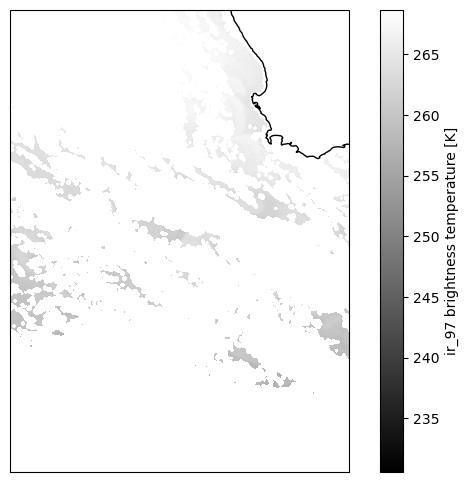

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(rrad.x, rrad.y, rrad.values, cmap ='gray', transform=ccrs.PlateCarree())
mask = ax.pcolormesh(clm.x, clm.y, np.ones_like(clm.values), 
                    alpha=alpha.values,color='white',shading='auto')
ax.coastlines()
ax.set_xlabel(rrad.x.values)
ax.set_ylabel(rrad.y.values)
plt.colorbar(im, ax=ax, label = f"{dataset_rrad} brightness temperature [K]")
plt.show()